# Solar Panel Defect Detection

This project classifies solar panel images into six types - Bird-drop, Clean, Dusty, Electrical-damage, Physical-Damage and Snow-Covered. 
I used a pretrained model called EfficientNetB0 and fine-tuned it on a dataset of 885 images.

## Installing packages

First I need to install all the libraries required for this project.

In [1]:
import sys
!{sys.executable} -m pip install tensorflow==2.13.0 opencv-python matplotlib seaborn scikit-learn pillow -q
print('Installation done')

Installation done


ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)

[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow==2.13.0


## Importing libraries

Importing everything I need. TensorFlow is for building and training the model, OpenCV reads and resizes images, 
scikit-learn handles data splitting and evaluation metrics, and matplotlib and seaborn are used for plotting.

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## Basic settings

Setting the dataset path, image size and other values I will use throughout the notebook. 
The image size is 224x224 because that is what EfficientNetB0 was originally trained on. 
A random seed is set so results stay the same every time the notebook is run.

In [3]:
DATASET    = 'Faultysolarpanels'
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
SEED       = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if not os.path.exists(DATASET):
    raise FileNotFoundError(f'Folder not found: {DATASET}. Place it in the same directory as this notebook.')

CLASSES   = sorted([d for d in os.listdir(DATASET)
                    if os.path.isdir(os.path.join(DATASET, d)) and not d.startswith('.')])
CLASS_IDX = {c: i for i, c in enumerate(CLASSES)}

print('Classes found:', CLASSES)

Classes found: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


## Counting images in each class

Before building the model I want to see how many images are in each class. 
This helps me understand whether the data is balanced or not.

In [4]:
counts = {}
for cls in CLASSES:
    folder = os.path.join(DATASET, cls)
    imgs = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    counts[cls] = len(imgs)

print(f"{'Class':<25} {'Images':>6}")
print('-' * 33)
for cls, n in counts.items():
    print(f'{cls:<25} {n:>6}')
print('-' * 33)
print(f"{'Total':<25} {sum(counts.values()):>6}")

Class                     Images
---------------------------------
Bird-drop                    191
Clean                        193
Dusty                        190
Electrical-damage            103
Physical-Damage               69
Snow-Covered                 123
---------------------------------
Total                        869


## Class distribution chart

Plotting the class counts as a bar chart and pie chart. 
Physical-Damage only has 69 images while Bird-drop and Clean have close to 200. 
This imbalance means the model might get biased towards predicting the majority classes, so I will handle this later using class weights.

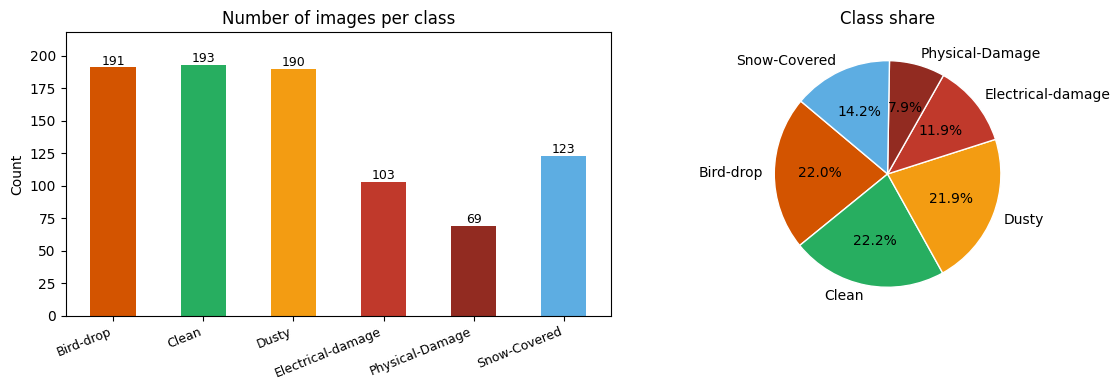

In [5]:
colors = ['#d35400', '#27ae60', '#f39c12', '#c0392b', '#922b21', '#5dade2']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(CLASSES, list(counts.values()), color=colors, width=0.5, edgecolor='none')
axes[0].set_title('Number of images per class')
axes[0].set_xticklabels(CLASSES, rotation=22, ha='right', fontsize=9)
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(counts.values()) + 25)
for bar, n in zip(bars, counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(n), ha='center', fontsize=9)

axes[1].pie(list(counts.values()), labels=CLASSES, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title('Class share')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## Sample images from each class

Looking at actual images gives a better idea of what makes each class different visually. 
Snow-covered panels look very bright. Dusty panels have a grey layer on top. 
Electrical damage shows burn marks. Physical damage shows cracks or broken areas.

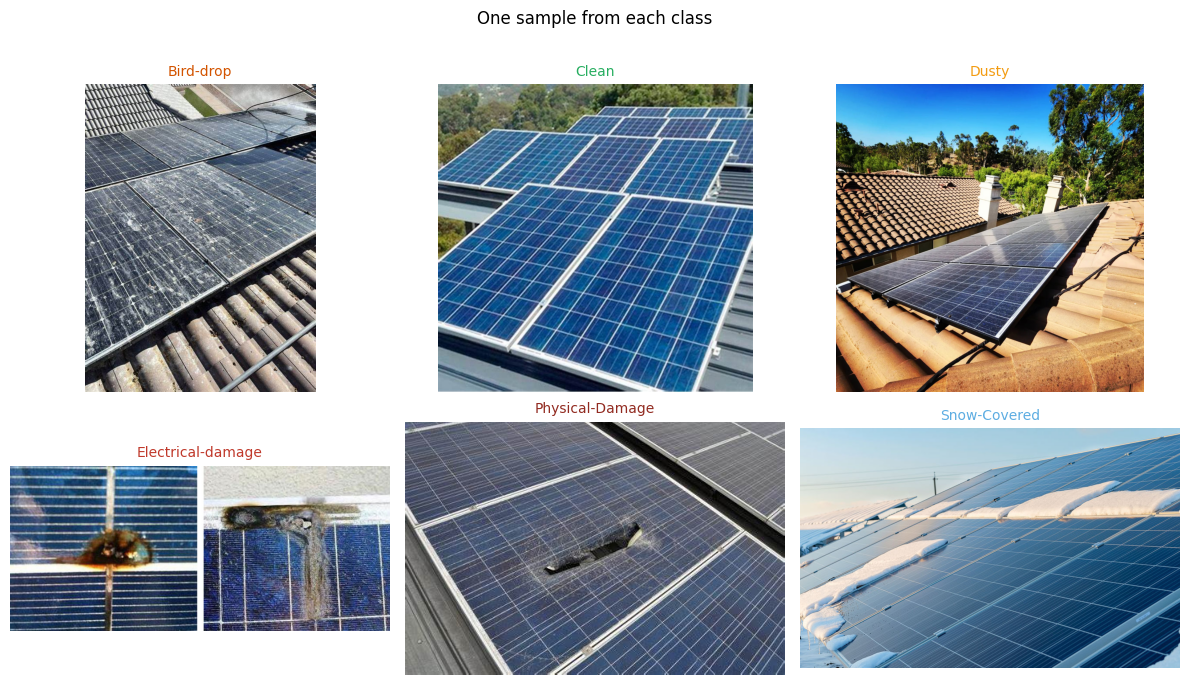

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, (cls, col) in enumerate(zip(CLASSES, colors)):
    folder = os.path.join(DATASET, cls)
    imgs = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img = Image.open(os.path.join(folder, random.choice(imgs))).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls, color=col, fontsize=10)
    axes[i].axis('off')

plt.suptitle('One sample from each class', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('eda_samples.png', dpi=100, bbox_inches='tight')
plt.show()

## Pixel intensity distributions

This shows how the pixel values are spread across the red, green and blue channels for each class. 
Snow-covered panels have very high pixel values because snow is bright. 
Electrical damage panels tend to be darker with some red channel spikes from burn marks. 
These differences are what the model will learn to pick up on.

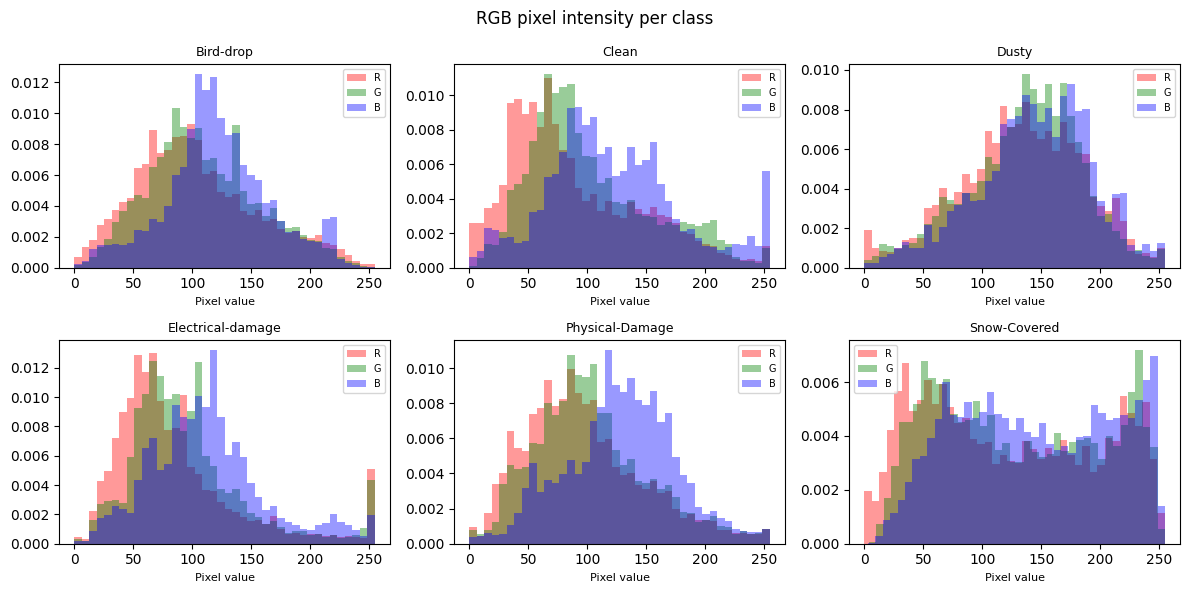

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, (cls, col) in enumerate(zip(CLASSES, colors)):
    folder = os.path.join(DATASET, cls)
    imgs = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    r_vals, g_vals, b_vals = [], [], []
    for f in random.sample(imgs, min(15, len(imgs))):
        arr = np.array(Image.open(os.path.join(folder, f)).convert('RGB').resize((64, 64)))
        r_vals += arr[:, :, 0].flatten().tolist()
        g_vals += arr[:, :, 1].flatten().tolist()
        b_vals += arr[:, :, 2].flatten().tolist()
    axes[i].hist(r_vals, bins=40, color='red',   alpha=0.4, density=True, label='R')
    axes[i].hist(g_vals, bins=40, color='green', alpha=0.4, density=True, label='G')
    axes[i].hist(b_vals, bins=40, color='blue',  alpha=0.4, density=True, label='B')
    axes[i].set_title(cls, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('Pixel value', fontsize=8)

plt.suptitle('RGB pixel intensity per class', fontsize=12)
plt.tight_layout()
plt.savefig('eda_rgb.png', dpi=100, bbox_inches='tight')
plt.show()

## Loading the images

Reading all the images from the dataset folder. Each image is resized to 224x224 and converted from BGR to RGB 
because OpenCV reads images in BGR format by default but the model expects RGB. 
The pixel values are kept as float32 in the range 0 to 255 because EfficientNetB0 does its own internal scaling.

In [8]:
def load_data(dataset_dir, classes, img_size):
    X, y = [], []
    skipped = 0
    for cls in classes:
        folder = os.path.join(dataset_dir, cls)
        for fname in os.listdir(folder):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            try:
                img = cv2.imread(os.path.join(folder, fname))
                if img is None:
                    skipped += 1
                    continue
                img = cv2.cvtColor(cv2.resize(img, img_size), cv2.COLOR_BGR2RGB)
                X.append(img.astype(np.float32))
                y.append(CLASS_IDX[cls])
            except Exception:
                skipped += 1
    print(f'Loaded: {len(X)} images, skipped: {skipped}')
    return np.array(X, dtype=np.float32), np.array(y)

X, y = load_data(DATASET, CLASSES, IMG_SIZE)
print('X shape:', X.shape)
print('y shape:', y.shape)

Loaded: 869 images, skipped: 0
X shape: (869, 224, 224, 3)
y shape: (869,)


## Splitting the data

Splitting the data into train, validation and test sets. 80 percent goes to training, 
10 percent to validation and 10 percent to testing. The stratify option makes sure each split 
has a fair share of all six classes. The labels are converted to one-hot vectors because the model 
outputs a probability for each class.

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

y_train_cat = to_categorical(y_train, len(CLASSES))
y_val_cat   = to_categorical(y_val,   len(CLASSES))
y_test_cat  = to_categorical(y_test,  len(CLASSES))

print(f'Train:      {len(X_train)} images')
print(f'Validation: {len(X_val)} images')
print(f'Test:       {len(X_test)} images')

Train:      695 images
Validation: 87 images
Test:       87 images


## Class weights

Since Physical-Damage and Electrical-damage have fewer images, the model would naturally pay less attention to them. 
Class weights fix this by increasing the penalty when the model gets minority class predictions wrong. 
The fewer images a class has, the higher its weight.

In [10]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

for i, cls in enumerate(CLASSES):
    print(f'{cls:<25} weight: {class_weights[i]:.3f}')

Bird-drop                 weight: 0.757
Clean                     weight: 0.752
Dusty                     weight: 0.762
Electrical-damage         weight: 1.396
Physical-Damage           weight: 2.106
Snow-Covered              weight: 1.182


## Data augmentation

With only 885 images the model could easily memorise the training data instead of learning to generalise. 
Augmentation randomly flips, rotates, shifts and changes the brightness of images during training. 
This way the model sees slightly different versions of the same image every epoch, 
which makes it better at handling images it has never seen before.

In [11]:
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)
datagen.fit(X_train)
print('Augmentation ready')

Augmentation ready


## Building the model

I am using EfficientNetB0 which was already trained on over a million images from ImageNet. 
This means it already knows how to detect edges, textures and shapes. 
I just need to add my own classification layers on top and teach it to tell apart the six solar panel conditions. 
The base model is frozen at first so only my new layers get trained. 
This prevents the pretrained weights from getting messed up at the start.

In [12]:
base = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base.trainable = False

x   = GlobalAveragePooling2D()(base.output)
x   = BatchNormalization()(x)
x   = Dense(512, activation='relu')(x)
x   = Dropout(0.5)(x)
x   = Dense(256, activation='relu')(x)
x   = Dropout(0.4)(x)
out = Dense(len(CLASSES), activation='softmax')(x)

model = Model(inputs=base.input, outputs=out)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model is ready')

Model is ready


## Checking the data before training

Just a quick check to make sure everything looks right before starting the long training process.

In [13]:
print('Training data shape:', X_train.shape)
print('Pixel range: min =', X_train.min(), ' max =', X_train.max())
print('Images per class in training set:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls:<25} {np.sum(y_train == i)}')
print('Ready to train')

Training data shape: (695, 224, 224, 3)
Pixel range: min = 0.0  max = 255.0
Images per class in training set:
  Bird-drop                 153
  Clean                     154
  Dusty                     152
  Electrical-damage         83
  Physical-Damage           55
  Snow-Covered              98
Ready to train


## Training the model - phase 1

In the first phase only the top layers are trained while the EfficientNetB0 base stays frozen. 
Early stopping will stop training if validation accuracy does not improve for 8 epochs. 
The model checkpoint saves the best version automatically so I do not lose good results.

In [14]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('solar_panel_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('Starting phase 1...')
history1 = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=30,
    validation_data=(X_val, y_val_cat),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
print(f'Best validation accuracy: {max(history1.history["val_accuracy"])*100:.2f}%')

Starting phase 1...
Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.3356 - loss: 2.1839
Epoch 1: val_accuracy improved from None to 0.59770, saving model to solar_panel_model.h5



Epoch 1: finished saving model to solar_panel_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 47s 873ms/step - accuracy: 0.4212 - loss: 1.9002 - val_accuracy: 0.5977 - val_loss: 1.0480 - learning_rate: 0.0010
Epoch 2/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 18s 435ms/step - accuracy: 0.6875 - loss: 1.0727
Epoch 2: val_accuracy improved from 0.59770 to 0.63218, saving model to solar_panel_model.h5



Epoch 2: finished saving model to solar_panel_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.6875 - loss: 1.0727 - val_accuracy: 0.6322 - val_loss: 1.0330 - learning_rate: 0.0010
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.6022 - loss: 1.1299
Epoch 3: val_accuracy improved from 0.63218 to 0.71264, saving model to solar_panel_model.h5



Epoch 3: finished saving model to solar_panel_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 415ms/step - accuracy: 0.6259 - loss: 1.0411 - val_accuracy: 0.7126 - val_loss: 0.8750 - learning_rate: 0.0010
Epoch 4/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 17s 424ms/step - accuracy: 0.6250 - loss: 1.1559
Epoch 4: val_accuracy did not improve from 0.71264
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6250 - loss: 1.1559 - val_accuracy: 0.7126 - val_loss: 0.8724 - learning_rate: 0.0010
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.6451 - loss: 0.9873
Epoch 5: val_accuracy did not improve from 0.71264
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 378ms/step - accuracy: 0.6541 - loss: 1.0211 - val_accuracy: 0.6552 - val_loss: 0.8647 - learning_rate: 0.0010
Epoch 6/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - accuracy: 0.5714 - loss: 1.2520
Epoch 6: val_accuracy did not improve from 0.71264
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5714 - loss: 1.2520 - val_accuracy: 0.6552 - val_loss:


Epoch 7: finished saving model to solar_panel_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 400ms/step - accuracy: 0.6937 - loss: 0.8518 - val_accuracy: 0.7356 - val_loss: 0.6717 - learning_rate: 0.0010
Epoch 8/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 17s 410ms/step - accuracy: 0.6250 - loss: 1.0420
Epoch 8: val_accuracy improved from 0.73563 to 0.75862, saving model to solar_panel_model.h5



Epoch 8: finished saving model to solar_panel_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6250 - loss: 1.0420 - val_accuracy: 0.7586 - val_loss: 0.6652 - learning_rate: 0.0010
Epoch 9/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.7342 - loss: 0.6958
Epoch 9: val_accuracy improved from 0.75862 to 0.78161, saving model to solar_panel_model.h5



Epoch 9: finished saving model to solar_panel_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 387ms/step - accuracy: 0.7275 - loss: 0.7461 - val_accuracy: 0.7816 - val_loss: 0.5802 - learning_rate: 0.0010
Epoch 10/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 16s 389ms/step - accuracy: 0.7500 - loss: 0.8748
Epoch 10: val_accuracy did not improve from 0.78161
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7500 - loss: 0.8748 - val_accuracy: 0.7816 - val_loss: 0.5870 - learning_rate: 0.0010
Epoch 11/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.7692 - loss: 0.6300
Epoch 11: val_accuracy improved from 0.78161 to 0.79310, saving model to solar_panel_model.h5



Epoch 11: finished saving model to solar_panel_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 403ms/step - accuracy: 0.7761 - loss: 0.6079 - val_accuracy: 0.7931 - val_loss: 0.5689 - learning_rate: 0.0010
Epoch 12/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 16s 389ms/step - accuracy: 0.8125 - loss: 0.5119
Epoch 12: val_accuracy did not improve from 0.79310
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8125 - loss: 0.5119 - val_accuracy: 0.7816 - val_loss: 0.5708 - learning_rate: 0.0010
Epoch 13/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.7507 - loss: 0.6599
Epoch 13: val_accuracy did not improve from 0.79310
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 377ms/step - accuracy: 0.7544 - loss: 0.6433 - val_accuracy: 0.7931 - val_loss: 0.6013 - learning_rate: 0.0010
Epoch 14/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 8s 201ms/step - accuracy: 0.7143 - loss: 0.6648
Epoch 14: val_accuracy did not improve from 0.79310
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7143 - loss: 0.6648 - val_accuracy: 0.7931 - va


Epoch 15: finished saving model to solar_panel_model.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 393ms/step - accuracy: 0.7673 - loss: 0.5746 - val_accuracy: 0.8506 - val_loss: 0.6392 - learning_rate: 0.0010
Epoch 16/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 16s 383ms/step - accuracy: 0.8125 - loss: 0.4536
Epoch 16: val_accuracy did not improve from 0.85057
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8125 - loss: 0.4536 - val_accuracy: 0.8506 - val_loss: 0.6369 - learning_rate: 3.0000e-04
Epoch 17/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.8218 - loss: 0.5097
Epoch 17: val_accuracy did not improve from 0.85057
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 385ms/step - accuracy: 0.8041 - loss: 0.5340 - val_accuracy: 0.8046 - val_loss: 0.5309 - learning_rate: 3.0000e-04
Epoch 18/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 18s 440ms/step - accuracy: 0.8125 - loss: 0.4493
Epoch 18: val_accuracy did not improve from 0.85057
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8125 - loss: 0.4493 - val_accuracy: 0.

## Fine-tuning the model - phase 2

Now I unfreeze the entire base model and train everything together at a much lower learning rate. 
The low learning rate is important because I do not want to destroy the pretrained weights. 
I just want to make small adjustments so the model adapts better to solar panel images.

In [15]:
base.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Starting phase 2 fine-tuning...')
history2 = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=30,
    validation_data=(X_val, y_val_cat),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
print(f'Best validation accuracy: {max(history2.history["val_accuracy"])*100:.2f}%')
print('Model saved as solar_panel_model.h5')

Starting phase 2 fine-tuning...
Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5008 - loss: 1.3519
Epoch 1: val_accuracy did not improve from 0.85057
43/43 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.4875 - loss: 1.3926 - val_accuracy: 0.8276 - val_loss: 0.5334 - learning_rate: 1.0000e-05
Epoch 2/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 1:15 2s/step - accuracy: 0.5000 - loss: 1.0322
Epoch 2: val_accuracy did not improve from 0.85057
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5000 - loss: 1.0322 - val_accuracy: 0.8276 - val_loss: 0.5339 - learning_rate: 1.0000e-05
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5185 - loss: 1.4438
Epoch 3: val_accuracy did not improve from 0.85057
43/43 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.5228 - loss: 1.4732 - val_accuracy: 0.7586 - val_loss: 0.5996 - learning_rate: 1.0000e-05
Epoch 4/30
 1/43 ━━━━━━━━━━━━━━━━━━━━ 1:11 2s/step - accuracy: 0.3750 - loss: 1.0100
Epoch 4: ReduceLROnPlateau reducing learning rat

## Training and validation curves

Plotting accuracy and loss over epochs for both training phases. 
The dashed line shows where phase 2 started. 
If the training and validation lines are close together it means the model is not overfitting.

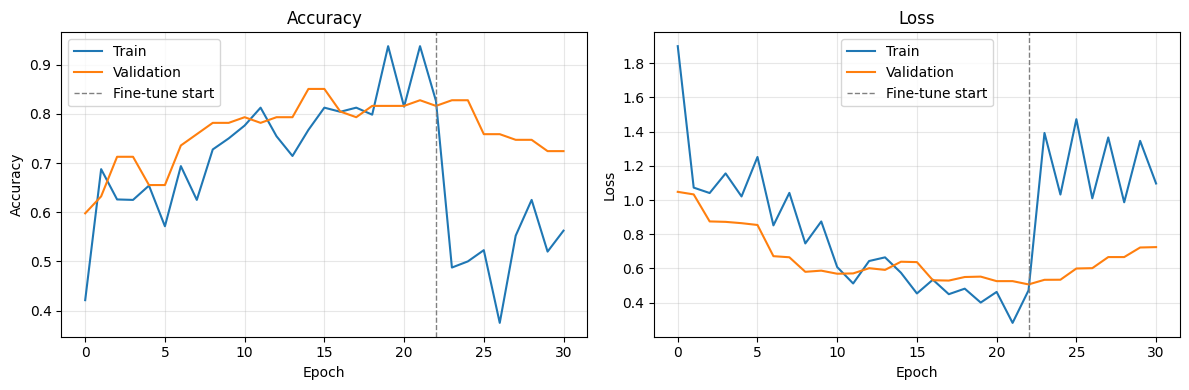

In [16]:
acc   = history1.history['accuracy']    + history2.history['accuracy']
val   = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss  = history1.history['loss']         + history2.history['loss']
vloss = history1.history['val_loss']     + history2.history['val_loss']
split = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(acc,  label='Train')
axes[0].plot(val,  label='Validation')
axes[0].axvline(x=split-1, color='gray', linestyle='--', linewidth=1, label='Fine-tune start')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(loss,  label='Train')
axes[1].plot(vloss, label='Validation')
axes[1].axvline(x=split-1, color='gray', linestyle='--', linewidth=1, label='Fine-tune start')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## Testing the model

Now I test the model on the test set which it has never seen during training. 
The classification report shows precision, recall and F1-score for each class separately, 
which gives a clearer picture than just looking at overall accuracy.

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test accuracy : {test_acc * 100:.2f}%')
print(f'Test loss     : {test_loss:.4f}')
print()
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=CLASSES))

Test accuracy : 79.31%
Test loss     : 0.6369

                   precision    recall  f1-score   support

        Bird-drop       0.74      0.89      0.81        19
            Clean       0.88      0.75      0.81        20
            Dusty       0.75      0.63      0.69        19
Electrical-damage       0.67      1.00      0.80        10
  Physical-Damage       0.80      0.57      0.67         7
     Snow-Covered       1.00      0.92      0.96        12

         accuracy                           0.79        87
        macro avg       0.81      0.79      0.79        87
     weighted avg       0.81      0.79      0.79        87



## Confusion matrix

The confusion matrix shows which classes the model got right and which ones it confused with each other. 
The diagonal shows correct predictions. Numbers off the diagonal are mistakes.

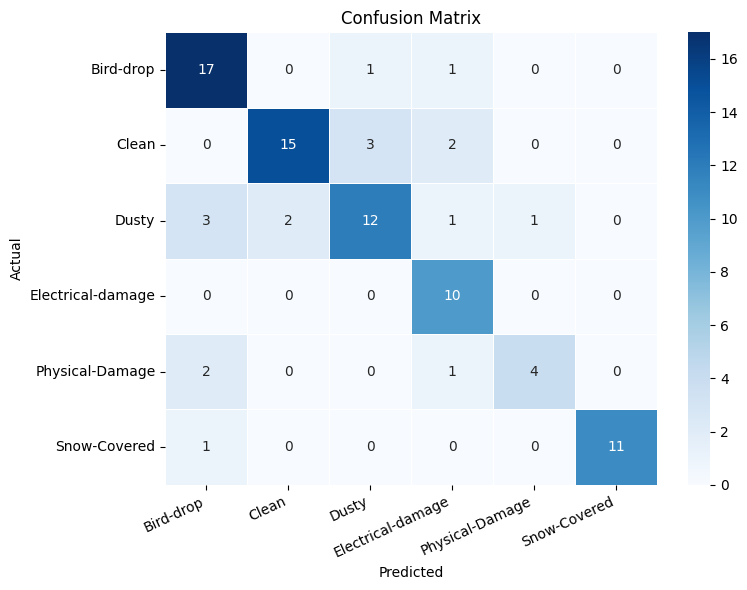

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## Predicting on a single image

This function takes any image, runs it through the model and shows the predicted class along with the confidence for all six classes.

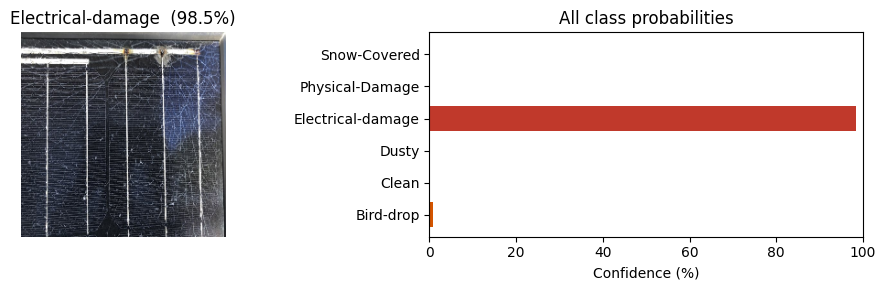

Predicted : Electrical-damage
Confidence: 98.5%


In [19]:
def predict_image(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(cv2.resize(img, IMG_SIZE), cv2.COLOR_BGR2RGB)
    inp = np.expand_dims(img_rgb.astype(np.float32), axis=0)
    preds = model.predict(inp, verbose=0)[0]
    idx   = np.argmax(preds)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'{CLASSES[idx]}  ({preds[idx]*100:.1f}%)')
    axes[0].axis('off')
    axes[1].barh(CLASSES, preds * 100, color=colors)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_xlim(0, 100)
    axes[1].set_title('All class probabilities')
    plt.tight_layout()
    plt.show()
    print(f'Predicted : {CLASSES[idx]}')
    print(f'Confidence: {preds[idx]*100:.1f}%')


sample_class  = CLASSES[3]
sample_folder = os.path.join(DATASET, sample_class)
sample_file   = [f for f in os.listdir(sample_folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))][0]
predict_image(os.path.join(sample_folder, sample_file))